# Kerr Circular EMRIs in Accretion Disks — Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://colab.research.google.com/github/stephengreen/DirtyEMRI-tutorial/blob/main/Playground_KerrCircularAccretion.ipynb)

## Setup

**On Google Colab:** run the **first code cell**. It installs the dependencies and then
**restarts the runtime — this is expected and normal.** After it restarts, choose
**Runtime → Run all**: the second cell builds the model (~2-3 min) and the physics runs.

**Locally (via `pixi run lab`):** the two setup cells are a no-op — the build already
happened. Just run the notebook top to bottom.


> ### On Colab, two things during setup look alarming but are normal — don't panic
>
> 1. **A block of red `ERROR: pip's dependency resolver...` text** about `numpy`.
>    That's just Colab's *other* preinstalled packages (opencv, jax, ...) preferring a
>    newer NumPy. **The install succeeded** and we don't use those packages — ignore it.
>
> 2. **The runtime restarts after the first cell** (you may see *"Your session
>    crashed / restarted"*). **This is intentional** — it gives a clean NumPy. When it
>    reconnects, just choose **Runtime → Run all** and setup continues automatically.


In [ ]:
# === Colab setup 1/2: install dependencies, then restart the runtime (once). ===
# After the restart, choose 'Runtime -> Run all'. This cell then skips; cell 2 builds.
# (No-op when running locally via pixi.)
import sys, os
if "google.colab" in sys.modules and not os.path.exists("/content/.few_setup_done"):
    if not os.path.exists("/content/DirtyEMRI-tutorial"):
        !git clone --depth 1 https://github.com/stephengreen/DirtyEMRI-tutorial.git /content/DirtyEMRI-tutorial
    # system C libraries. Ubuntu/Colab ship GSL 2.7 — exactly what this fork needs (2.8 breaks it).
    !apt-get -qq update && apt-get -qq install -y libgsl-dev liblapacke-dev libhdf5-dev
    # Ubuntu names the hdf5 libs *_serial; add unversioned symlinks so -lhdf5 / -lhdf5_hl link.
    !ln -sf /usr/lib/x86_64-linux-gnu/libhdf5_serial.so    /usr/lib/x86_64-linux-gnu/libhdf5.so
    !ln -sf /usr/lib/x86_64-linux-gnu/libhdf5_serial_hl.so /usr/lib/x86_64-linux-gnu/libhdf5_hl.so
    # python build/runtime deps (numpy<2 matches the fork's C API)
    !pip install -q "numpy<2" "cython<3" scipy h5py tqdm requests matplotlib
    open("/content/.few_setup_done", "w").close()
    print("\n*** Dependencies installed. Restarting the runtime now - THIS IS EXPECTED. ***")
    print("*** When it comes back, choose  Runtime -> Run all.\n")
    os.kill(os.getpid(), 9)   # force a clean restart so the freshly installed numpy loads correctly


In [ ]:
# === Colab setup 2/2: build the fork for THIS kernel, then import it. ===
import sys, os, pathlib
if "google.colab" in sys.modules:
    os.chdir("/content/DirtyEMRI-tutorial")
    os.environ["CPATH"] = "/usr/include/hdf5/serial:" + os.environ.get("CPATH", "")  # hdf5 headers
    !{sys.executable} build_few.py     # build with this kernel's python so the .so matches it

# Make `import few` (and its compiled extensions) resolve here — Colab or local pixi alike.
_few_dir = pathlib.Path.cwd() / "FastEMRIWaveforms"
if _few_dir.exists() and str(_few_dir) not in sys.path:
    sys.path.insert(0, str(_few_dir))
import importlib; importlib.invalidate_caches()
from few.trajectory.inspiral import EMRIInspiral  # sanity check
print("FastEMRIWaveforms ready - KerrCircFlux available.")


# Playground for Kerr Circular Orbits
In this note book you can explore how Kerr Circular Orbits work. An extensive tutorial about the usage of the trajectories can be found [here](https://github.com/lorenzsp/GRAPPA_EMRI_tutorial/blob/main/EMRI_Waveforms_in_a_nutshell.ipynb). The disk interaction included in this trajectory module is from [https://arxiv.org/abs/2207.10086](https://arxiv.org/abs/2207.10086).

In [8]:
import numpy as np
import warnings

from few.trajectory.inspiral import EMRIInspiral
from few.amplitude.romannet import RomanAmplitude
from few.amplitude.interp2dcubicspline import Interp2DAmplitude
from few.waveform import FastSchwarzschildEccentricFlux, SlowSchwarzschildEccentricFlux
from few.utils.utility import get_overlap, get_mismatch, get_separatrix, get_fundamental_frequencies, get_fundamental_frequencies_spin_corrections
from few.utils.ylm import GetYlms
from few.utils.modeselector import ModeSelector
from few.summation.interpolatedmodesum import CubicSplineInterpolant
from few.utils.constants import *
import matplotlib.pyplot as plt

# define 1 year in seconds for later use
year_in_seconds = 365.25 * 24 * 3600

try:
    import cupy as xp

    gpu_available = True

except (ModuleNotFoundError, ImportError) as e:
    import numpy as xp

    warnings.warn(
        "CuPy is not installed or a gpu is not available. If trying to run on a gpu, please install CuPy."
    )
    gpu_available = False

# here you decide which trajectory to use. KerrCircFlux is the default and the one where we have implemented the disk corrections, 
# so it's the one we will use in this tutorial,
# but you can also use KerrEccFlux, SchwarzschildEccFlux, or even a custom one if you have it implemented.
traj = EMRIInspiral(func="KerrCircFlux")

/Users/pmzls1/Documents/Projects/BHsEnvironmentaleffects/Migration EMRIs/DirtyEMRI-tutorial/FastEMRIWaveforms/few/trajectory/../../
/Users/pmzls1/Documents/Projects/BHsEnvironmentaleffects/Migration EMRIs/DirtyEMRI-tutorial/FastEMRIWaveforms/few/trajectory/../../


/var/folders/7j/mmw81qxs79d3tmffc_nyrhj00000gq/T/ipykernel_25782/3597648265.py:26: UserWarning: CuPy is not installed or a gpu is not available. If trying to run on a gpu, please install CuPy.
  warnings.warn(


The EMRI paramters are
- the mass of the supermassive black hole (M) 
- the mass of the secondary ($\mu$) 
- the initial radius $p=r/M$
- the intiial eccentricity $e_0$
- the primary black hole spin $a$
- the initial inclination $x_0=\cos(\theta)$
- the intial phases $\phi_{\phi,0}$, $\phi_{\theta,0}$ and $\phi_{r,0}$

The disk torque parameters are $A_{\rm disk}$ and $n_{\rm disk}$, with the disk torque given by
$$     T_{\rm disk} = A_{\rm disk} (r/10 M)^{n_{\rm disk}} \dot{L}_{\rm gw} \, , $$

You can also set the duration of your trajectory/waveform, $T$, and the time step $dt$.

First we generate the vacuum trajectory, and plot the evolution of the EMRI:

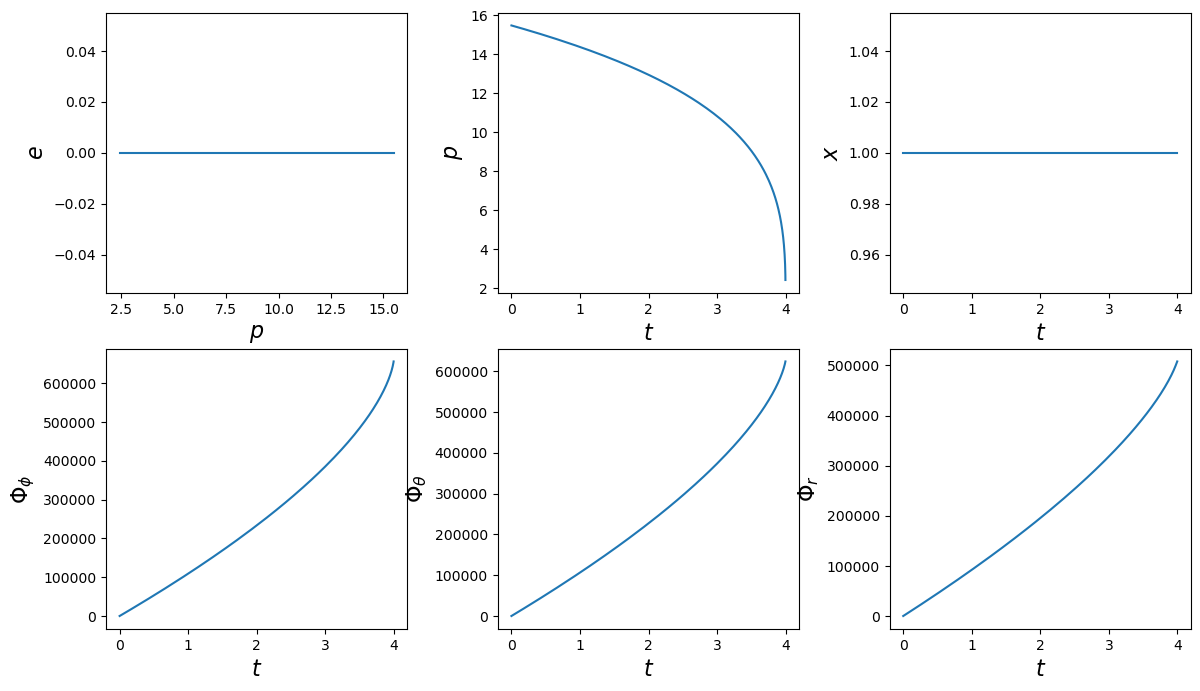

In [10]:
# parameter of https://arxiv.org/pdf/2207.10086.pdf
# set initial parameters
M = 1e6
mu = 50.0
p0 = 15.482608237080893
e0 = 0.0
a = 0.9
x0 = 1.0

# run trajectory
T = 4.0 # years
dt = 10.0
phiphi0, phitheta, phir = 0, 0, 0

# without accretion
t, p, e, x, Phi_phi, Phi_theta, Phi_r = traj(M, mu, a, p0, e0, x0, 0.0, 0, 0, T=T, dt=dt)
tfinal = t[-1]
spline_noAcc = CubicSplineInterpolant(t, np.stack((p, e, x, Phi_phi, Phi_theta, Phi_r)) )

fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.3)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [r'$e$', r'$p$', r'$x$', r'$\Phi_\phi$', r'$\Phi_\theta$', r'$\Phi_r$']
xlabels = [r'$p$', r'$t$', r'$t$', r'$t$', r'$t$', r'$t$', r'$t$',r'$t$']
ys = [e, p, x, Phi_phi, Phi_theta, Phi_r]
xs = [p, t/year_in_seconds, t/year_in_seconds, t/year_in_seconds, t/year_in_seconds, t/year_in_seconds]

for i, (ax, x, y, xlab, ylab) in enumerate(zip(axes, xs, ys, xlabels, ylabels)):
    ax.plot(x, y)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

Next we generate a few examples of the trajectory in the disk. We plot the phase as a function of time and frequency, with and without the disk interaction:

Text(0, 0.5, 'relative difference in phase')

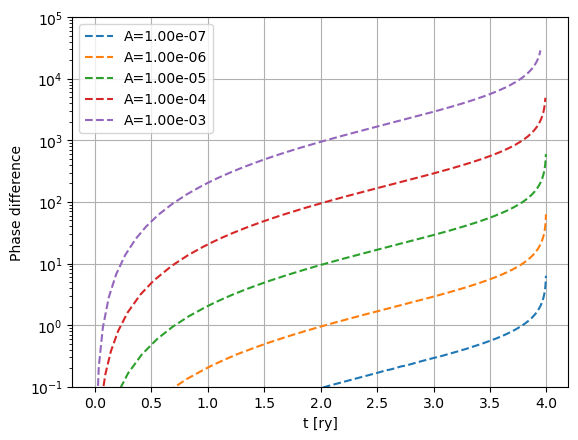

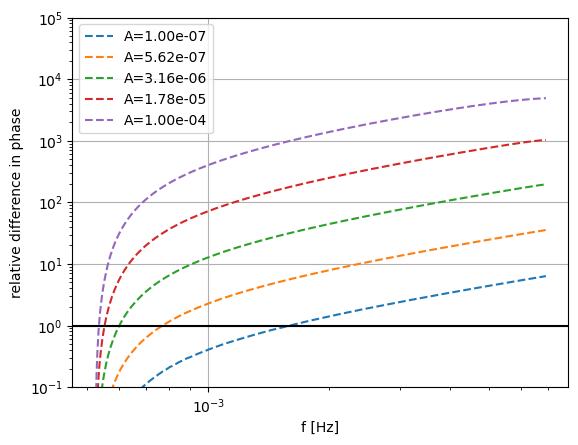

In [11]:
# accretion parameters from https://arxiv.org/abs/2207.10086
A = 1e-5
n = 8.0
# this is an extra parameter in cause you want to include a square-root component in the disk correction, 
# but in the paper we only include a power-law component, so we set it to 0.
m = 0.0 

plt.figure()
# with accretion
Avec = 10**np.linspace(-7,-3,num=5)
for A in Avec:
    t, p, e, x, Phi_phi, Phi_theta, Phi_r = traj(M, mu, a, p0, e0, x0, A, n, m, T=T, dt=dt)
    spline = CubicSplineInterpolant(t, np.stack((p, e, x, Phi_phi, Phi_theta, Phi_r)) )
    plt.semilogy(t/(YRSID_SI), np.abs(spline(t)[3]-spline_noAcc(t)[3]),'--',label=f'A={A:.2e}')

plt.legend()
plt.xlabel('t [ry]')
plt.ylim([1e-1,1e5])
plt.grid()
plt.ylabel('Phase difference')

plt.figure()
# with accretion
Avec = 10**np.linspace(-7,-4,num=5)
for A in Avec:
    t, p, e, x, Phi_phi, Phi_theta, Phi_r = traj(M, mu, a, p0, e0, x0, A, n, m, T=T, dt=dt)
    spline = CubicSplineInterpolant(t, np.stack((p, e, x, Phi_phi, Phi_theta, Phi_r)) )
    f = get_fundamental_frequencies(a, *spline(t)[:3])[0] / (2*np.pi*M*MTSUN_SI)
    plt.loglog(f, np.abs(spline(t)[3]-spline_noAcc(t)[3]),'--',label=f'A={A:.2e}')

plt.axhline(1, color='k')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylim([1e-1,1e5])
plt.grid()
plt.ylabel('relative difference in phase')


We can also plot the total phase difference at the end of the observation time, as a function of the disk torque amplitude, for two different values of the power-law index $n_{\rm disk}$:

Text(0, 0.5, 'Phase difference at the end of the trajectory')

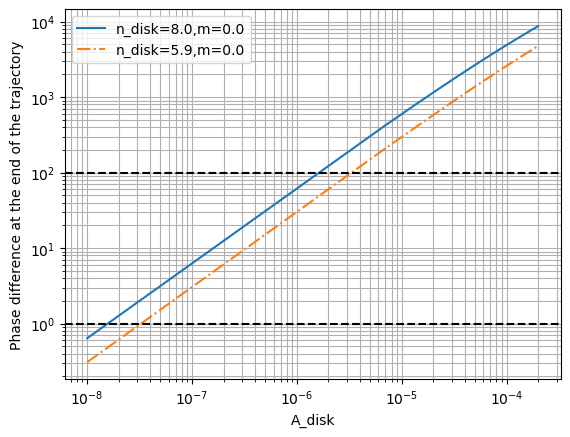

In [12]:
plt.figure()
for n,m,lintype in zip([8.0, 5.9], [0.0, 0.0], ['-', '-.']):#[-28/5, -12.0]
    deph = []
    Avec = np.linspace(0.1e-7,2e-4,num=30)
    for A in Avec:
        # with accretion
        t, p, e, x, Phi_phi, Phi_theta, Phi_r = traj(M, mu, a, p0, e0, x0, A, n, m, T=T, dt=dt)
        spline = CubicSplineInterpolant(t, np.stack((p, e, x, Phi_phi, Phi_theta, Phi_r)) )
        deph.append(np.max(np.abs(spline(t)[3]-spline_noAcc(t)[3])) )

    plt.loglog(Avec, deph,lintype,label=f'n_disk={n},m={m}')

plt.legend()
plt.axhline(1.0,linestyle='--',color='k')
plt.axhline(100.0,linestyle='--',color='k')
plt.xlabel('A_disk')
# plt.ylim([1e-1,1e3])
plt.grid(True, which="both")
plt.ylabel('Phase difference at the end of the trajectory')
# similar to the phase difference of Fig 1 https://arxiv.org/pdf/2207.10086.pdf

Finally, we look at $dp/dt$, the ODE that is directly affected by the disk interaction.

In [15]:
# to obtain the right hand side of the ODE you can use
pdot, edot, Ydot, OmegaPhi, OmegaTheta, OmegaR = traj.get_derivative(mu/M, a, p0, e0, x0, np.asarray([A, n, m]))

# range
pvec = np.linspace(3.0, 30.0,dtype=float)

# check that diff is small
# diff = np.asarray([1-traj.get_derivative(mu/M, a, pp, 0.0, 1.0, np.asarray([A, n, m]))[3] /
# get_fundamental_frequencies(np.ones(1)*a, np.ones(1)*pp, np.ones(1)*1e-10, np.ones(1)*1.0-1e-10)[0] 
# # (1 / a + pp**(3/2))
# for pp in pvec])

From
$$ \frac{dL}{dt} =\frac{dL}{dp}\frac{dp}{dt} = \dot{L}_{\rm gw} + \dot{L}_{\rm disk}$$
we should find
$$\left.\frac{dp}{dt}\right|_{\rm disk} - \left.\frac{dp}{dt}\right|_{\rm vacuum} = \dot{L}_{\rm disk} / \frac{dL}{dp}  = A_{\rm disk} (r/10 M)^{n_{\rm disk}} \dot{L}_{\rm gw}/ \frac{dL}{dp} $$


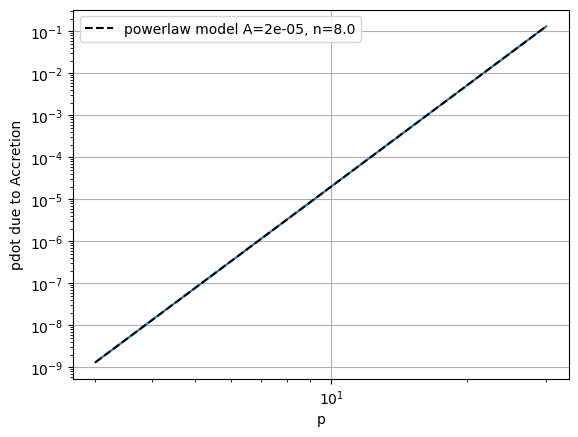

max diff 7.133858059837905e-09


In [16]:
A, n, m = 2e-5, 8.0, 0.0

# evolve sytem
pdot_evolution_Accretion = np.asarray([traj.get_derivative(mu/M, a, pp, 0.0, 1.0, np.asarray([A, n, m]))[0] for pp in pvec])
pdot_evolution_NoAccretion = np.asarray([traj.get_derivative(mu/M, a, pp, 0.0, 1.0, np.asarray([0.0, n, m]))[0] for pp in pvec])

def Power(x,a):
    return x**a
def Sqrt(x):
    return np.sqrt(x)

dL_dp = ((-3*Power(a,3) + Power(a,2)*(8 - 3*pvec)*Sqrt(pvec) + (-6 + pvec)*Power(pvec,2.5) + 3*a*pvec*(-2 + 3*pvec))/(2.*Power(2*a + (-3 + pvec)*Sqrt(pvec),1.5)*Power(pvec,1.75)))

LdotPN = -32./5. * mu/M *Power(pvec, -7./2.)

factor = LdotPN / dL_dp

plt.figure()
plt.loglog(pvec, (pdot_evolution_Accretion-pdot_evolution_NoAccretion) / (factor) )
# plt.loglog(pvec, pdot_evolution_NoAccretion/factor )
plt.loglog(pvec, A*(pvec/10.0)**(n),color='k',label=f'powerlaw model A={A}, n={n}', linestyle='--')
plt.ylabel('pdot due to Accretion')
plt.xlabel('p')
plt.grid()
plt.legend()
plt.show()

print("max diff",np.max(1-(pdot_evolution_Accretion-pdot_evolution_NoAccretion) / (factor) / ( A*(pvec/10.0)**(n)) ))

This way, we can compare different contributions to the ODE governing the EMRI radius $p$:
The role of the disk is small, but we have already seen that it can add up to a sizeable dephasing.

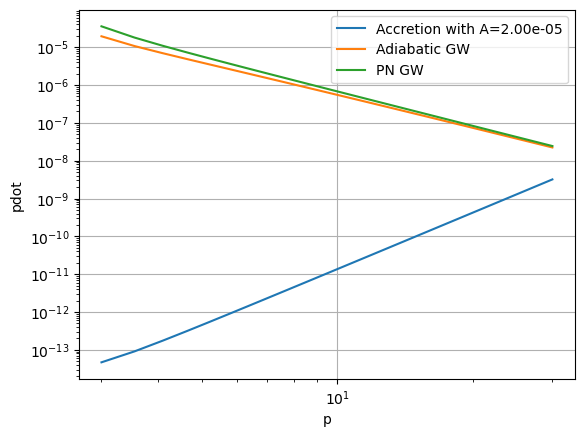

In [17]:

plt.figure()
plt.loglog(pvec, -A*(pvec/10.0)**(n) * LdotPN/dL_dp, label=f'Accretion with A={A:.2e}' )
plt.loglog(pvec, -pdot_evolution_NoAccretion, label='Adiabatic GW')
plt.loglog(pvec, -LdotPN/dL_dp, label='PN GW')

plt.ylabel('pdot')
plt.xlabel('p')
plt.grid()
plt.legend()
plt.show()